# 06 — Tell the driver circuit-specialization story

## Purpose

Turn the validated model results into a concise, evidence-led case study. This notebook separates overall outperformance from circuit specialization, interprets both directions of every circuit trait, and keeps limitations beside the findings they qualify.

This is a descriptive historical analysis—not a causal ranking of driver ability.

## Inputs

- `data/outputs/driver_specialization_scores.csv`
- `data/outputs/driver_track_model_results.csv`
- `data/outputs/model_summary_metrics.csv`
- `data/processed/driver_race_with_circuit_features.csv`
- Six validated figures from `README assets/`

All inputs were created and validated by Notebooks 3–5.

## Outputs

- `data/outputs/storytelling_summary.json`
- `data/outputs/storytelling_driver_profiles.csv`
- `data/outputs/storytelling_circuit_profiles.csv`
- `data/outputs/notebook_06_validation_report.json`

The output tables contain the evidence used in the narrative; no model is refit here.

## Imports

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

## Configuration

In [2]:
def find_project_root(start: Path) -> Path:
    """Find the project root from a notebook or project working directory."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ASSET_DIR = PROJECT_ROOT / "README assets"

INPUT_PATHS = {
    "driver_scores": OUTPUT_DIR / "driver_specialization_scores.csv",
    "model_rows": OUTPUT_DIR / "driver_track_model_results.csv",
    "model_summary": OUTPUT_DIR / "model_summary_metrics.csv",
    "circuit_features": PROCESSED_DIR / "driver_race_with_circuit_features.csv",
}

FIGURE_PATHS = {
    "specialists": ASSET_DIR / "01_driver_specialists.png",
    "heatmap": ASSET_DIR / "02_driver_specialization_heatmap.png",
    "versatility": ASSET_DIR / "03_versatility_vs_outperformance.png",
    "circuit_fingerprints": ASSET_DIR / "04_circuit_fingerprints.png",
    "residual_status": ASSET_DIR / "05_residuals_by_finish_status.png",
    "circuit_similarity": ASSET_DIR / "06_circuit_similarity.png",
}

OUTPUT_PATHS = {
    "summary": OUTPUT_DIR / "storytelling_summary.json",
    "drivers": OUTPUT_DIR / "storytelling_driver_profiles.csv",
    "circuits": OUTPUT_DIR / "storytelling_circuit_profiles.csv",
    "validation": OUTPUT_DIR / "notebook_06_validation_report.json",
}

MIN_CIRCUIT_OBSERVATIONS = 100
PROFILE_DRIVER_NAMES = [
    "Max Verstappen",
    "Fernando Alonso",
    "Lewis Hamilton",
    "Alexander Albon",
    "Daniel Ricciardo",
]

missing_inputs = [str(path) for path in [*INPUT_PATHS.values(), *FIGURE_PATHS.values()] if not path.exists()]
if missing_inputs:
    raise FileNotFoundError(f"Missing validated upstream inputs: {missing_inputs}")

## Helper functions

In [3]:
TRAIT_LABELS = {
    "speed": ("lower-speed", "higher-speed"),
    "technical": ("lower-technical", "more technical"),
    "downforce": ("lower-downforce", "higher-downforce"),
    "overtaking": ("overtaking-difficult", "overtaking-friendly"),
}


def percentage_points(value: float) -> float:
    """Convert a performance-share coefficient to percentage points."""
    return float(value * 100)


def strongest_preference(row: pd.Series) -> tuple[str, str, float]:
    """Return the trait, direction label, and signed slope with greatest magnitude."""
    slopes = {trait: float(row[f"{trait}_slope"]) for trait in TRAIT_LABELS}
    trait = max(slopes, key=lambda name: abs(slopes[name]))
    slope = slopes[trait]
    direction = TRAIT_LABELS[trait][1 if slope >= 0 else 0]
    return trait, direction, slope


def driver_interpretation(row: pd.Series) -> str:
    """Create a restrained, plain-language interpretation for one driver."""
    trait, direction, slope = strongest_preference(row)
    return (
        f"{row['driver_full_name']} averaged "
        f"{percentage_points(row['mean_baseline_residual']):+.1f} percentage points "
        f"relative to expectation. The largest modeled circuit tendency was toward "
        f"{direction} tracks ({percentage_points(slope):+.1f} points per +1 SD in {trait})."
    )


def json_ready(value: Any) -> Any:
    """Convert NumPy and pandas scalar values into JSON-safe Python values."""
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    return value


def validation_row(check: str, passed: bool, details: Any) -> dict[str, Any]:
    """Create one consistent validation record."""
    return {"check": check, "passed": bool(passed), "details": json_ready(details)}

## Processing

The story follows a deliberate order:

1. Establish what the baseline explains.
2. Separate overall outperformance from specialization.
3. Interpret notable drivers without treating slopes as grades.
4. Describe circuit separation as an exploratory signal—not proof that a circuit “exposes skill.”
5. Close with the limits of the evidence.

In [4]:
driver_scores = pd.read_csv(INPUT_PATHS["driver_scores"])
model_rows = pd.read_csv(INPUT_PATHS["model_rows"])
model_summary = pd.read_csv(INPUT_PATHS["model_summary"])
circuit_features = pd.read_csv(INPUT_PATHS["circuit_features"])

baseline = model_summary.loc[
    model_summary["model_name"].eq("baseline_expected_performance")
].iloc[0]
specialization_models = model_summary.loc[
    model_summary["model_name"].ne("baseline_expected_performance")
].copy()

correlation = driver_scores[
    ["specialization_magnitude", "mean_baseline_residual"]
].corr().iloc[0, 1]

selected_driver_profiles = (
    driver_scores.loc[driver_scores["driver_full_name"].isin(PROFILE_DRIVER_NAMES)]
    .copy()
    .sort_values("overall_outperformance_rank")
)
selected_driver_profiles["mean_outperformance_points"] = (
    selected_driver_profiles["mean_baseline_residual"].map(percentage_points)
)
selected_driver_profiles["strongest_preference"] = selected_driver_profiles.apply(
    lambda row: strongest_preference(row)[1], axis=1
)
selected_driver_profiles["strongest_slope_points"] = selected_driver_profiles.apply(
    lambda row: percentage_points(strongest_preference(row)[2]), axis=1
)
selected_driver_profiles["interpretation"] = selected_driver_profiles.apply(
    driver_interpretation, axis=1
)

driver_profile_columns = [
    "driver_id",
    "driver_full_name",
    "career_starts",
    "circuits_raced",
    "mean_outperformance_points",
    "overall_outperformance_rank",
    "specialization_magnitude",
    "versatility_rank",
    "strongest_preference",
    "strongest_slope_points",
    "interpretation",
]
storytelling_driver_profiles = selected_driver_profiles[driver_profile_columns].reset_index(drop=True)

circuit_separation = (
    model_rows.loc[model_rows["baseline_model_row"].eq(1)]
    .groupby(["circuit_id", "circuit_name"], as_index=False)
    .agg(
        observations=("baseline_residual", "size"),
        seasons=("season", "nunique"),
        mean_residual=("baseline_residual", "mean"),
        residual_std=("baseline_residual", "std"),
        mean_absolute_residual=("baseline_residual", lambda values: values.abs().mean()),
    )
)

circuit_metadata = (
    circuit_features[
        [
            "circuit_id",
            "circuit_type",
            "speed_score",
            "technical_score",
            "downforce_score",
            "overtaking_score",
            "primary_trait",
        ]
    ]
    .drop_duplicates("circuit_id")
)

storytelling_circuit_profiles = (
    circuit_separation.merge(circuit_metadata, on="circuit_id", how="left", validate="one_to_one")
    .loc[lambda frame: frame["observations"].ge(MIN_CIRCUIT_OBSERVATIONS)]
    .sort_values(["residual_std", "observations"], ascending=[False, False])
    .reset_index(drop=True)
)
storytelling_circuit_profiles["separation_rank"] = np.arange(
    1, len(storytelling_circuit_profiles) + 1
)
storytelling_circuit_profiles["interpretation"] = (
    "Historical baseline residuals were more dispersed here; this is performance separation, "
    "not a causal measure of driver skill."
)

top_outperformer = driver_scores.nsmallest(1, "overall_outperformance_rank").iloc[0]
most_versatile = driver_scores.nsmallest(1, "versatility_rank").iloc[0]

storytelling_summary = {
    "scope": {
        "seasons": [int(model_rows["season"].min()), int(model_rows["season"].max())],
        "modeled_driver_races": int(model_rows["baseline_model_row"].sum()),
        "eligible_drivers": int(len(driver_scores)),
        "circuits": int(model_rows["circuit_id"].nunique()),
    },
    "baseline": {
        "r_squared": float(baseline["r_squared"]),
        "adjusted_r_squared": float(baseline["adjusted_r_squared"]),
        "rmse": float(baseline["rmse"]),
    },
    "specialization": {
        "mean_r_squared": float(specialization_models["r_squared"].mean()),
        "mean_adjusted_r_squared": float(specialization_models["adjusted_r_squared"].mean()),
        "versatility_outperformance_correlation": float(correlation),
    },
    "headline_drivers": {
        "highest_mean_outperformance": str(top_outperformer["driver_full_name"]),
        "highest_mean_outperformance_points": percentage_points(
            top_outperformer["mean_baseline_residual"]
        ),
        "most_versatile": str(most_versatile["driver_full_name"]),
    },
    "interpretation_guardrails": [
        "Specialization is not an all-time driver ranking.",
        "A negative slope means preference for the opposite end of a trait, not poor performance.",
        "Performance separation by circuit is descriptive and is not proof of driver skill.",
        "The career-wide model does not support a causal comparison across eras.",
    ],
}

## Diagnostics

### The central result

The baseline explains **45.6%** of driver-race performance variation.
The four circuit models explain about **1.6%**
of the remaining variation before adjustment and
**0.3%** after adjustment.

Circuit specialization is present, but it is a secondary pattern.

### Versatility is not overall performance

Specialization magnitude and mean outperformance have a correlation of
**-0.18**. Drivers can therefore be versatile, strong relative to expectation,
both, or neither.


,driver_full_name,mean_outperformance_points,overall_outperformance_rank,versatility_rank,strongest_preference,strongest_slope_points
0,Max Verstappen,4.77,1,16,higher-downforce,1.37
1,Fernando Alonso,3.38,2,40,higher-downforce,2.54
2,Alexander Albon,2.56,5,1,lower-technical,-0.88
3,Lewis Hamilton,2.10,8,3,higher-downforce,0.91
4,Daniel Ricciardo,0.26,19,2,overtaking-difficult,-0.79


- Max Verstappen averaged +4.8 percentage points relative to expectation. The largest modeled circuit tendency was toward higher-downforce tracks (+1.4 points per +1 SD in downforce).

- Fernando Alonso averaged +3.4 percentage points relative to expectation. The largest modeled circuit tendency was toward higher-downforce tracks (+2.5 points per +1 SD in downforce).

- Alexander Albon averaged +2.6 percentage points relative to expectation. The largest modeled circuit tendency was toward lower-technical tracks (-0.9 points per +1 SD in technical).

- Lewis Hamilton averaged +2.1 percentage points relative to expectation. The largest modeled circuit tendency was toward higher-downforce tracks (+0.9 points per +1 SD in downforce).

- Daniel Ricciardo averaged +0.3 percentage points relative to expectation. The largest modeled circuit tendency was toward overtaking-difficult tracks (-0.8 points per +1 SD in overtaking).

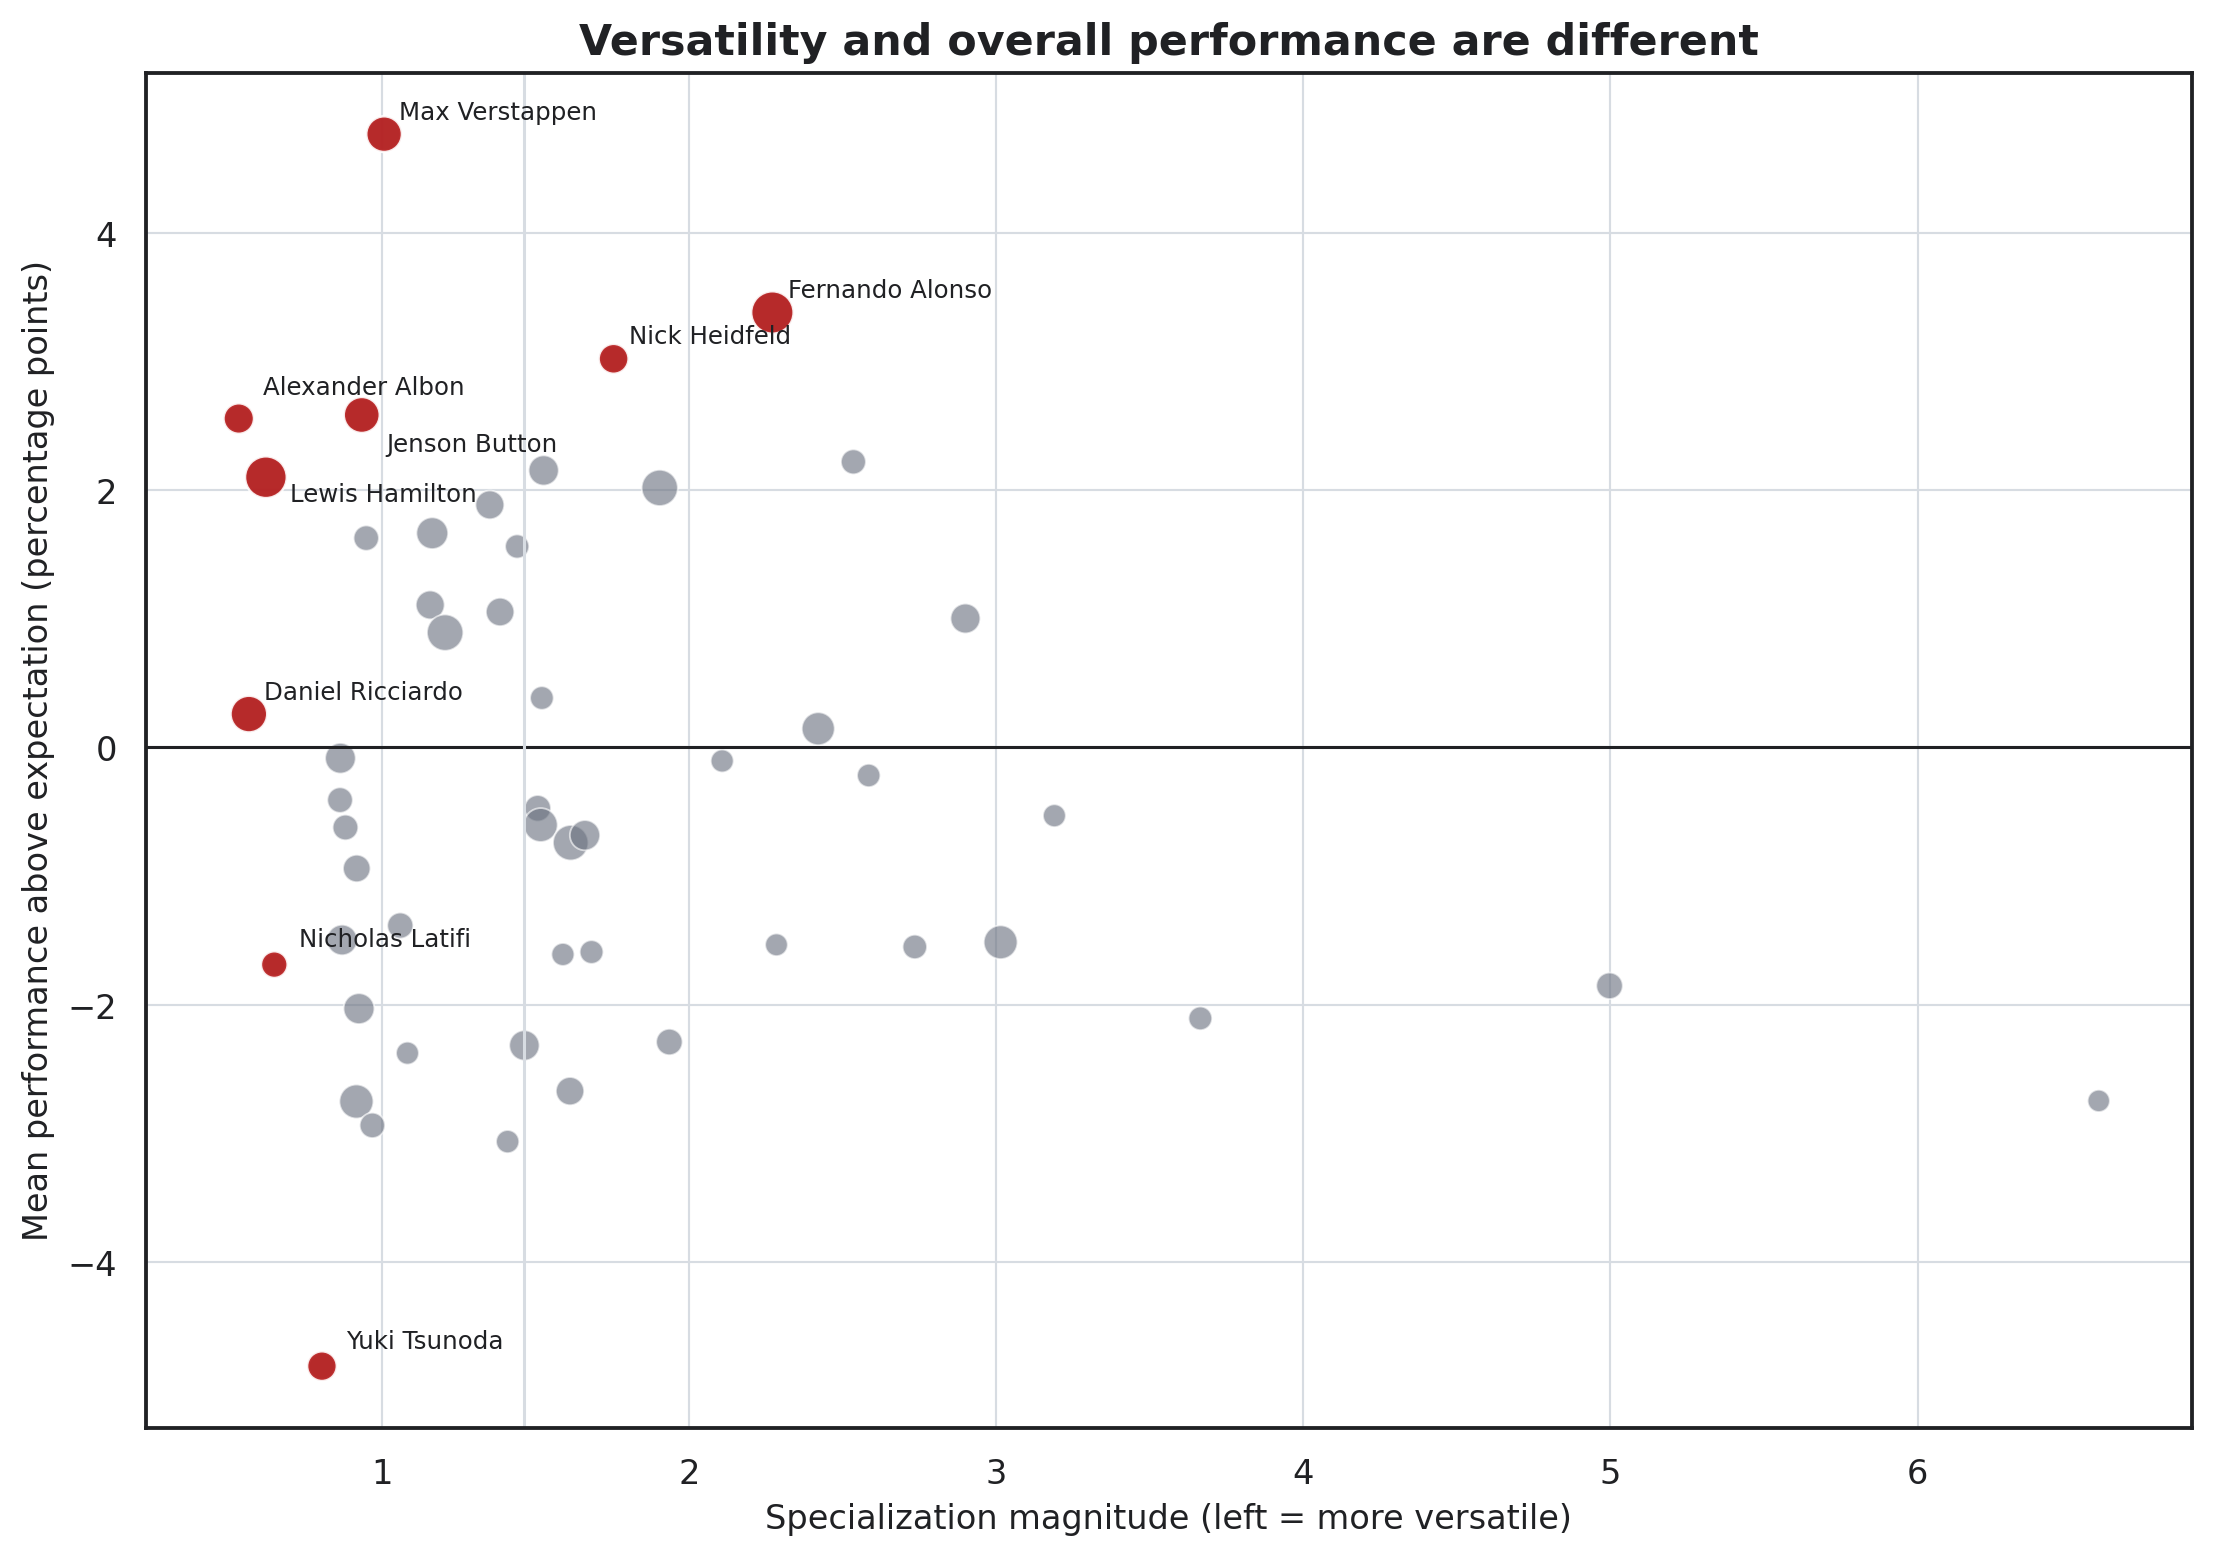

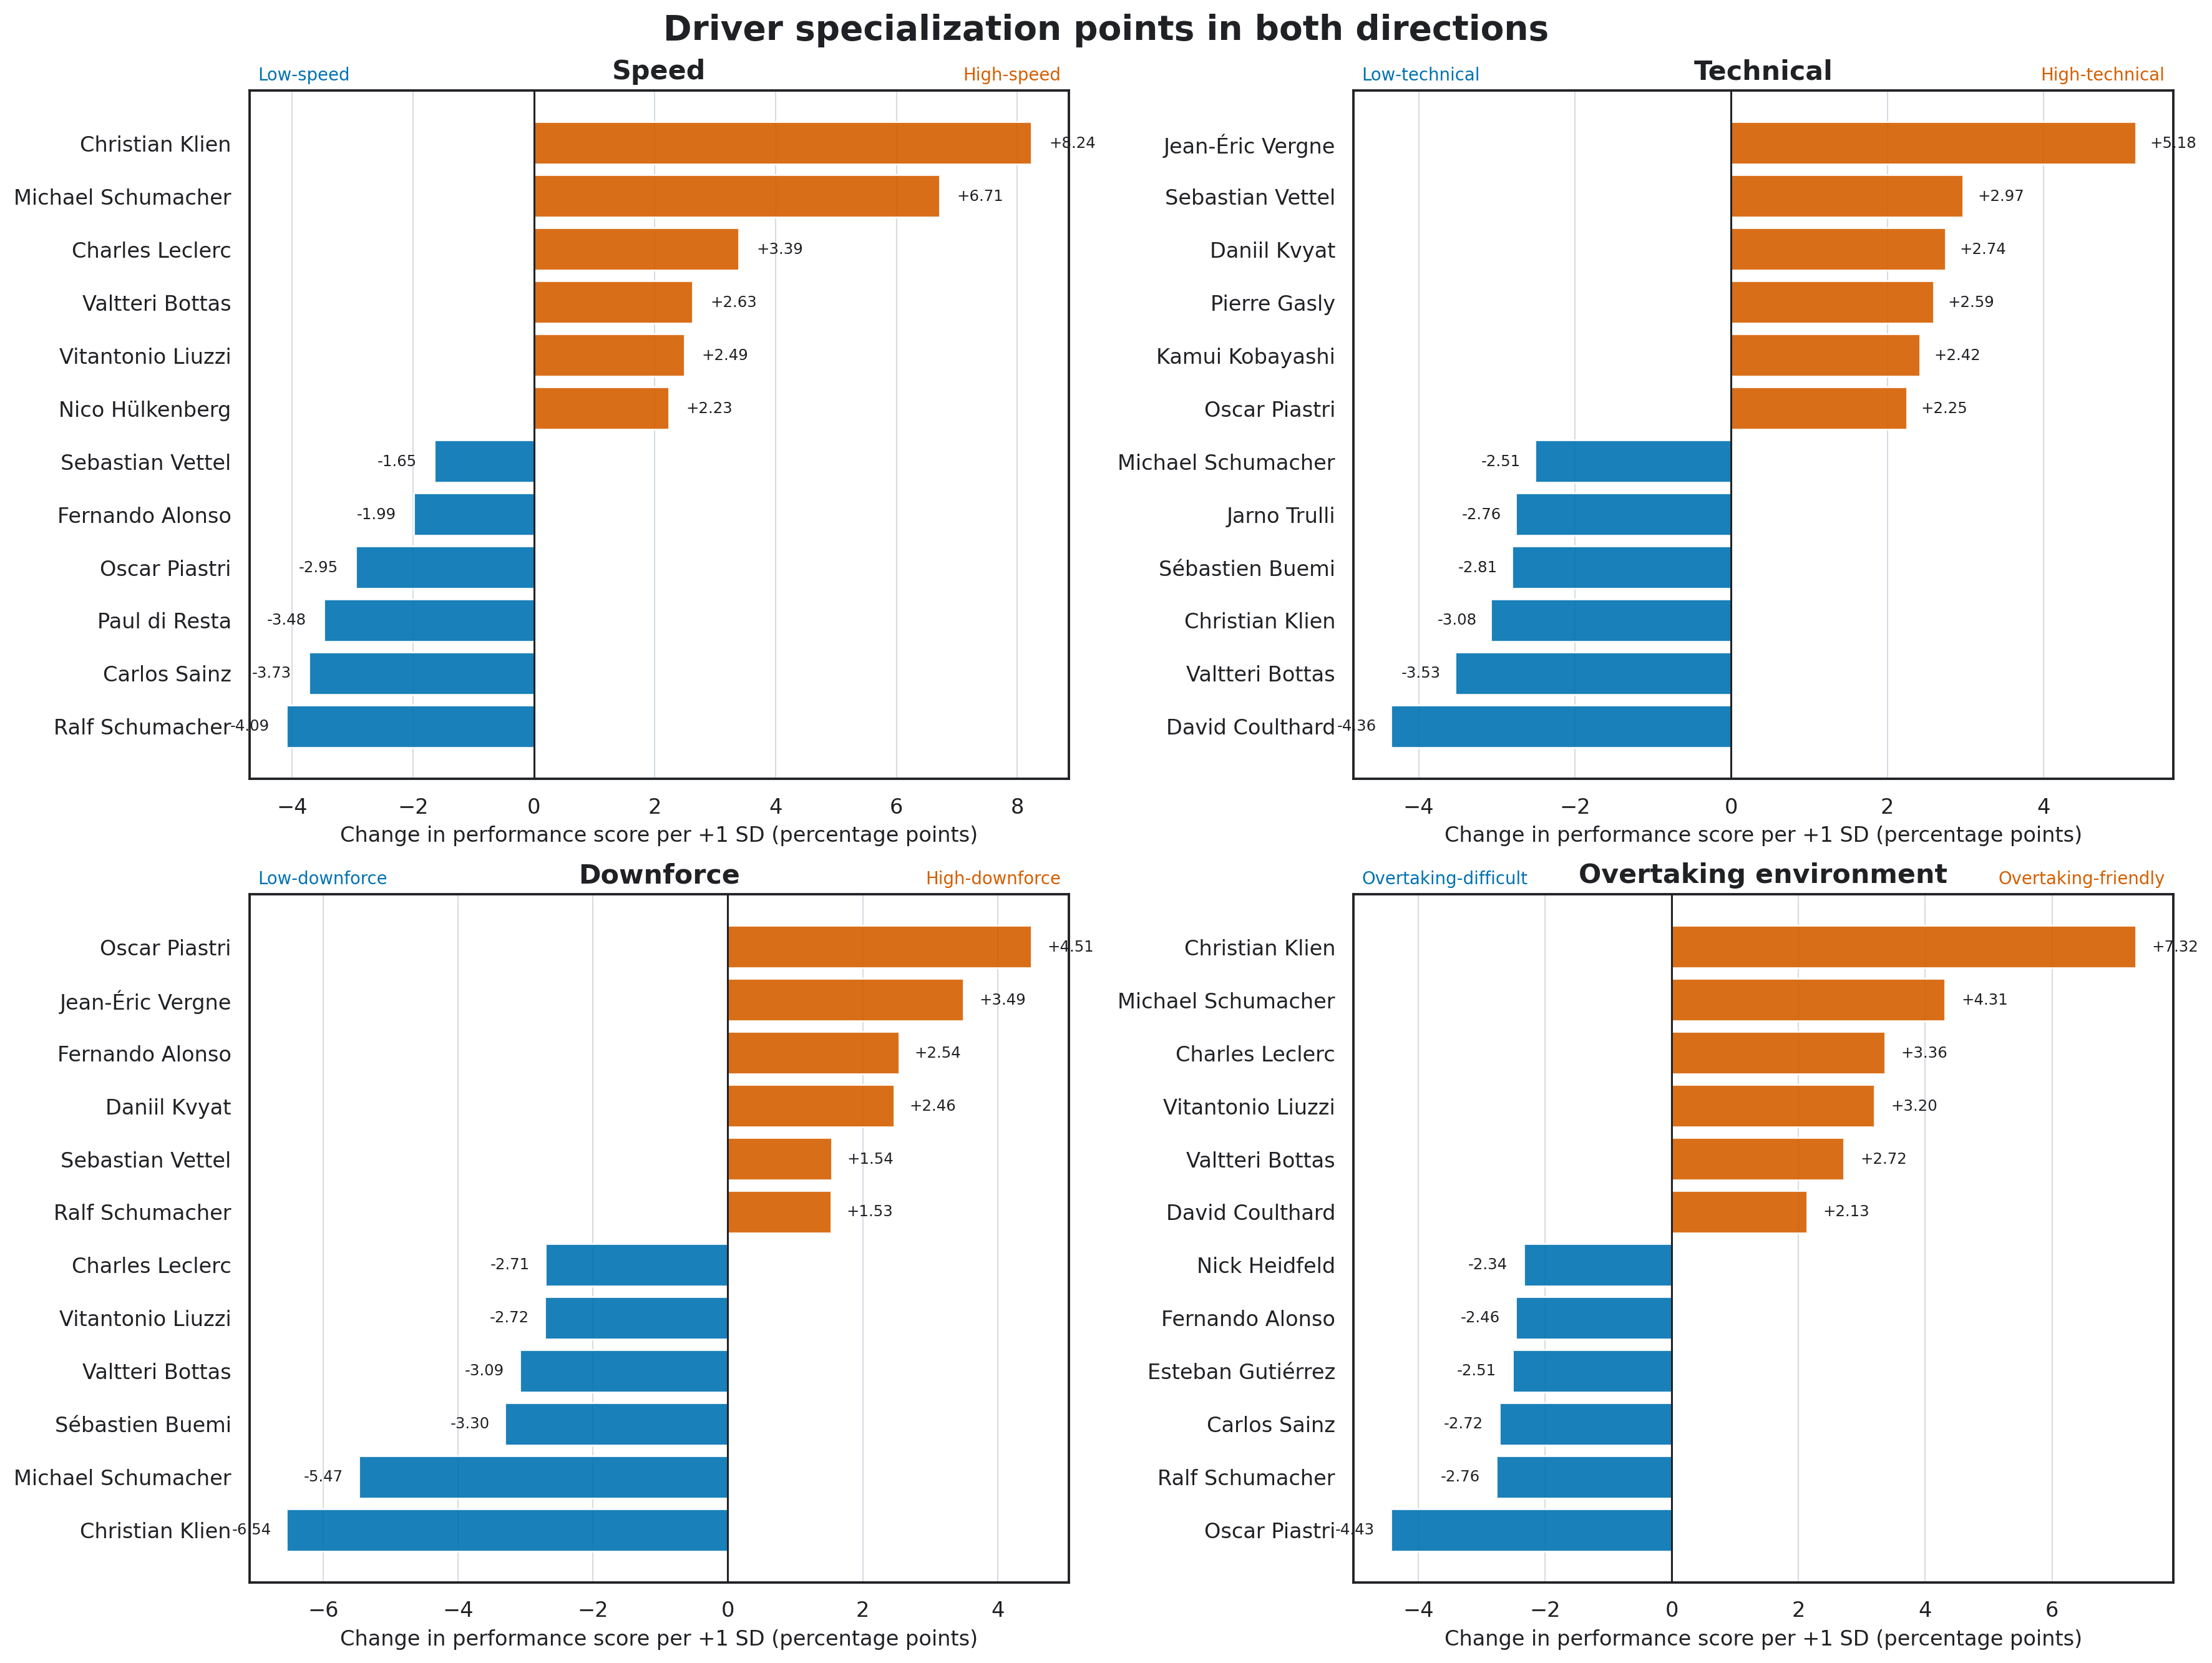

### Circuit fingerprints and performance separation

Circuit scores describe track profiles; they do not assign difficulty or quality.
The table below ranks circuits with at least 100 modeled observations by the historical
spread of baseline residuals. A wider spread may reflect incidents, reliability, weather,
field composition, or strategy as well as genuine driver-track interaction.


,separation_rank,circuit_name,observations,seasons,residual_std,circuit_type,primary_trait
0,1,Baku City Circuit,182,9,0.251,street,speed
1,2,Nurburgring,170,8,0.247,permanent,technical
2,3,Circuit de Spa-Francorchamps,439,21,0.242,permanent,speed
3,4,Albert Park Grand Prix Circuit,409,20,0.242,hybrid,speed
4,5,Valencia Street Circuit,111,5,0.241,street,speed
5,6,Hockenheimring,212,10,0.237,permanent,mixed
6,7,Marina Bay Street Circuit,336,16,0.231,street,mixed
7,8,Sepang International Circuit,303,14,0.231,permanent,speed
8,9,Red Bull Ring,283,12,0.230,permanent,mixed
9,10,Circuit Gilles Villeneuve,395,19,0.229,hybrid,mixed


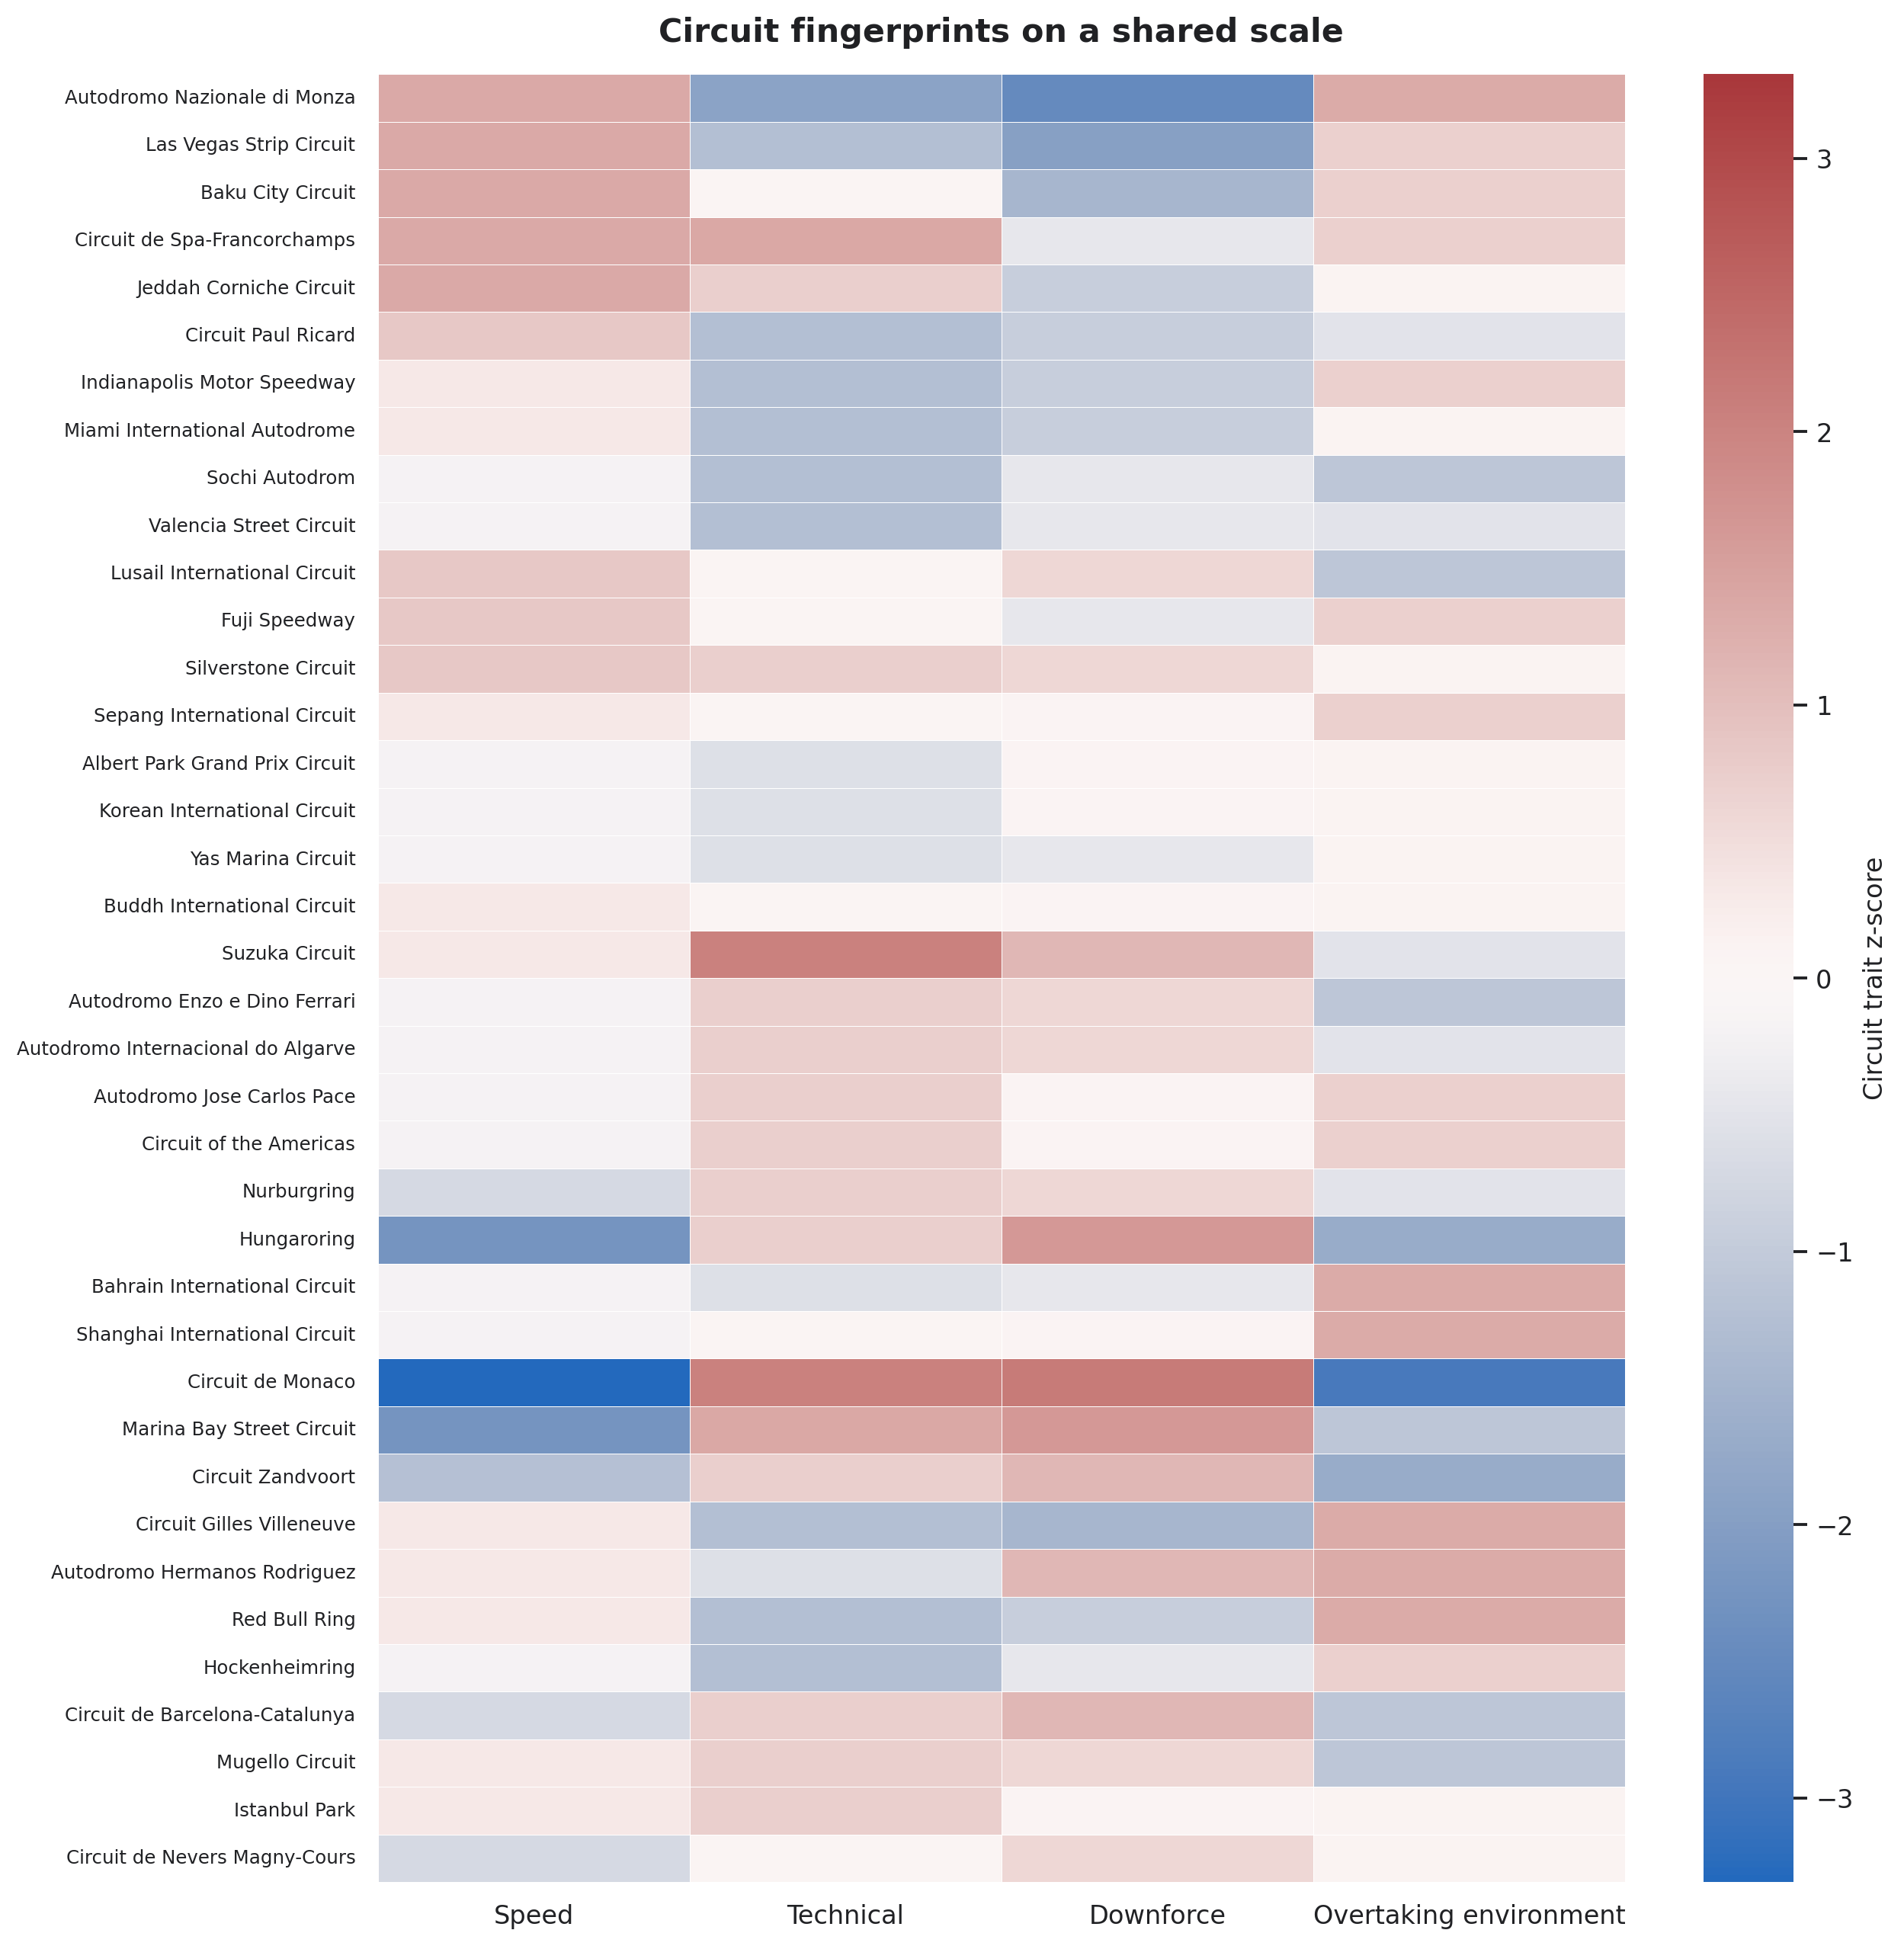

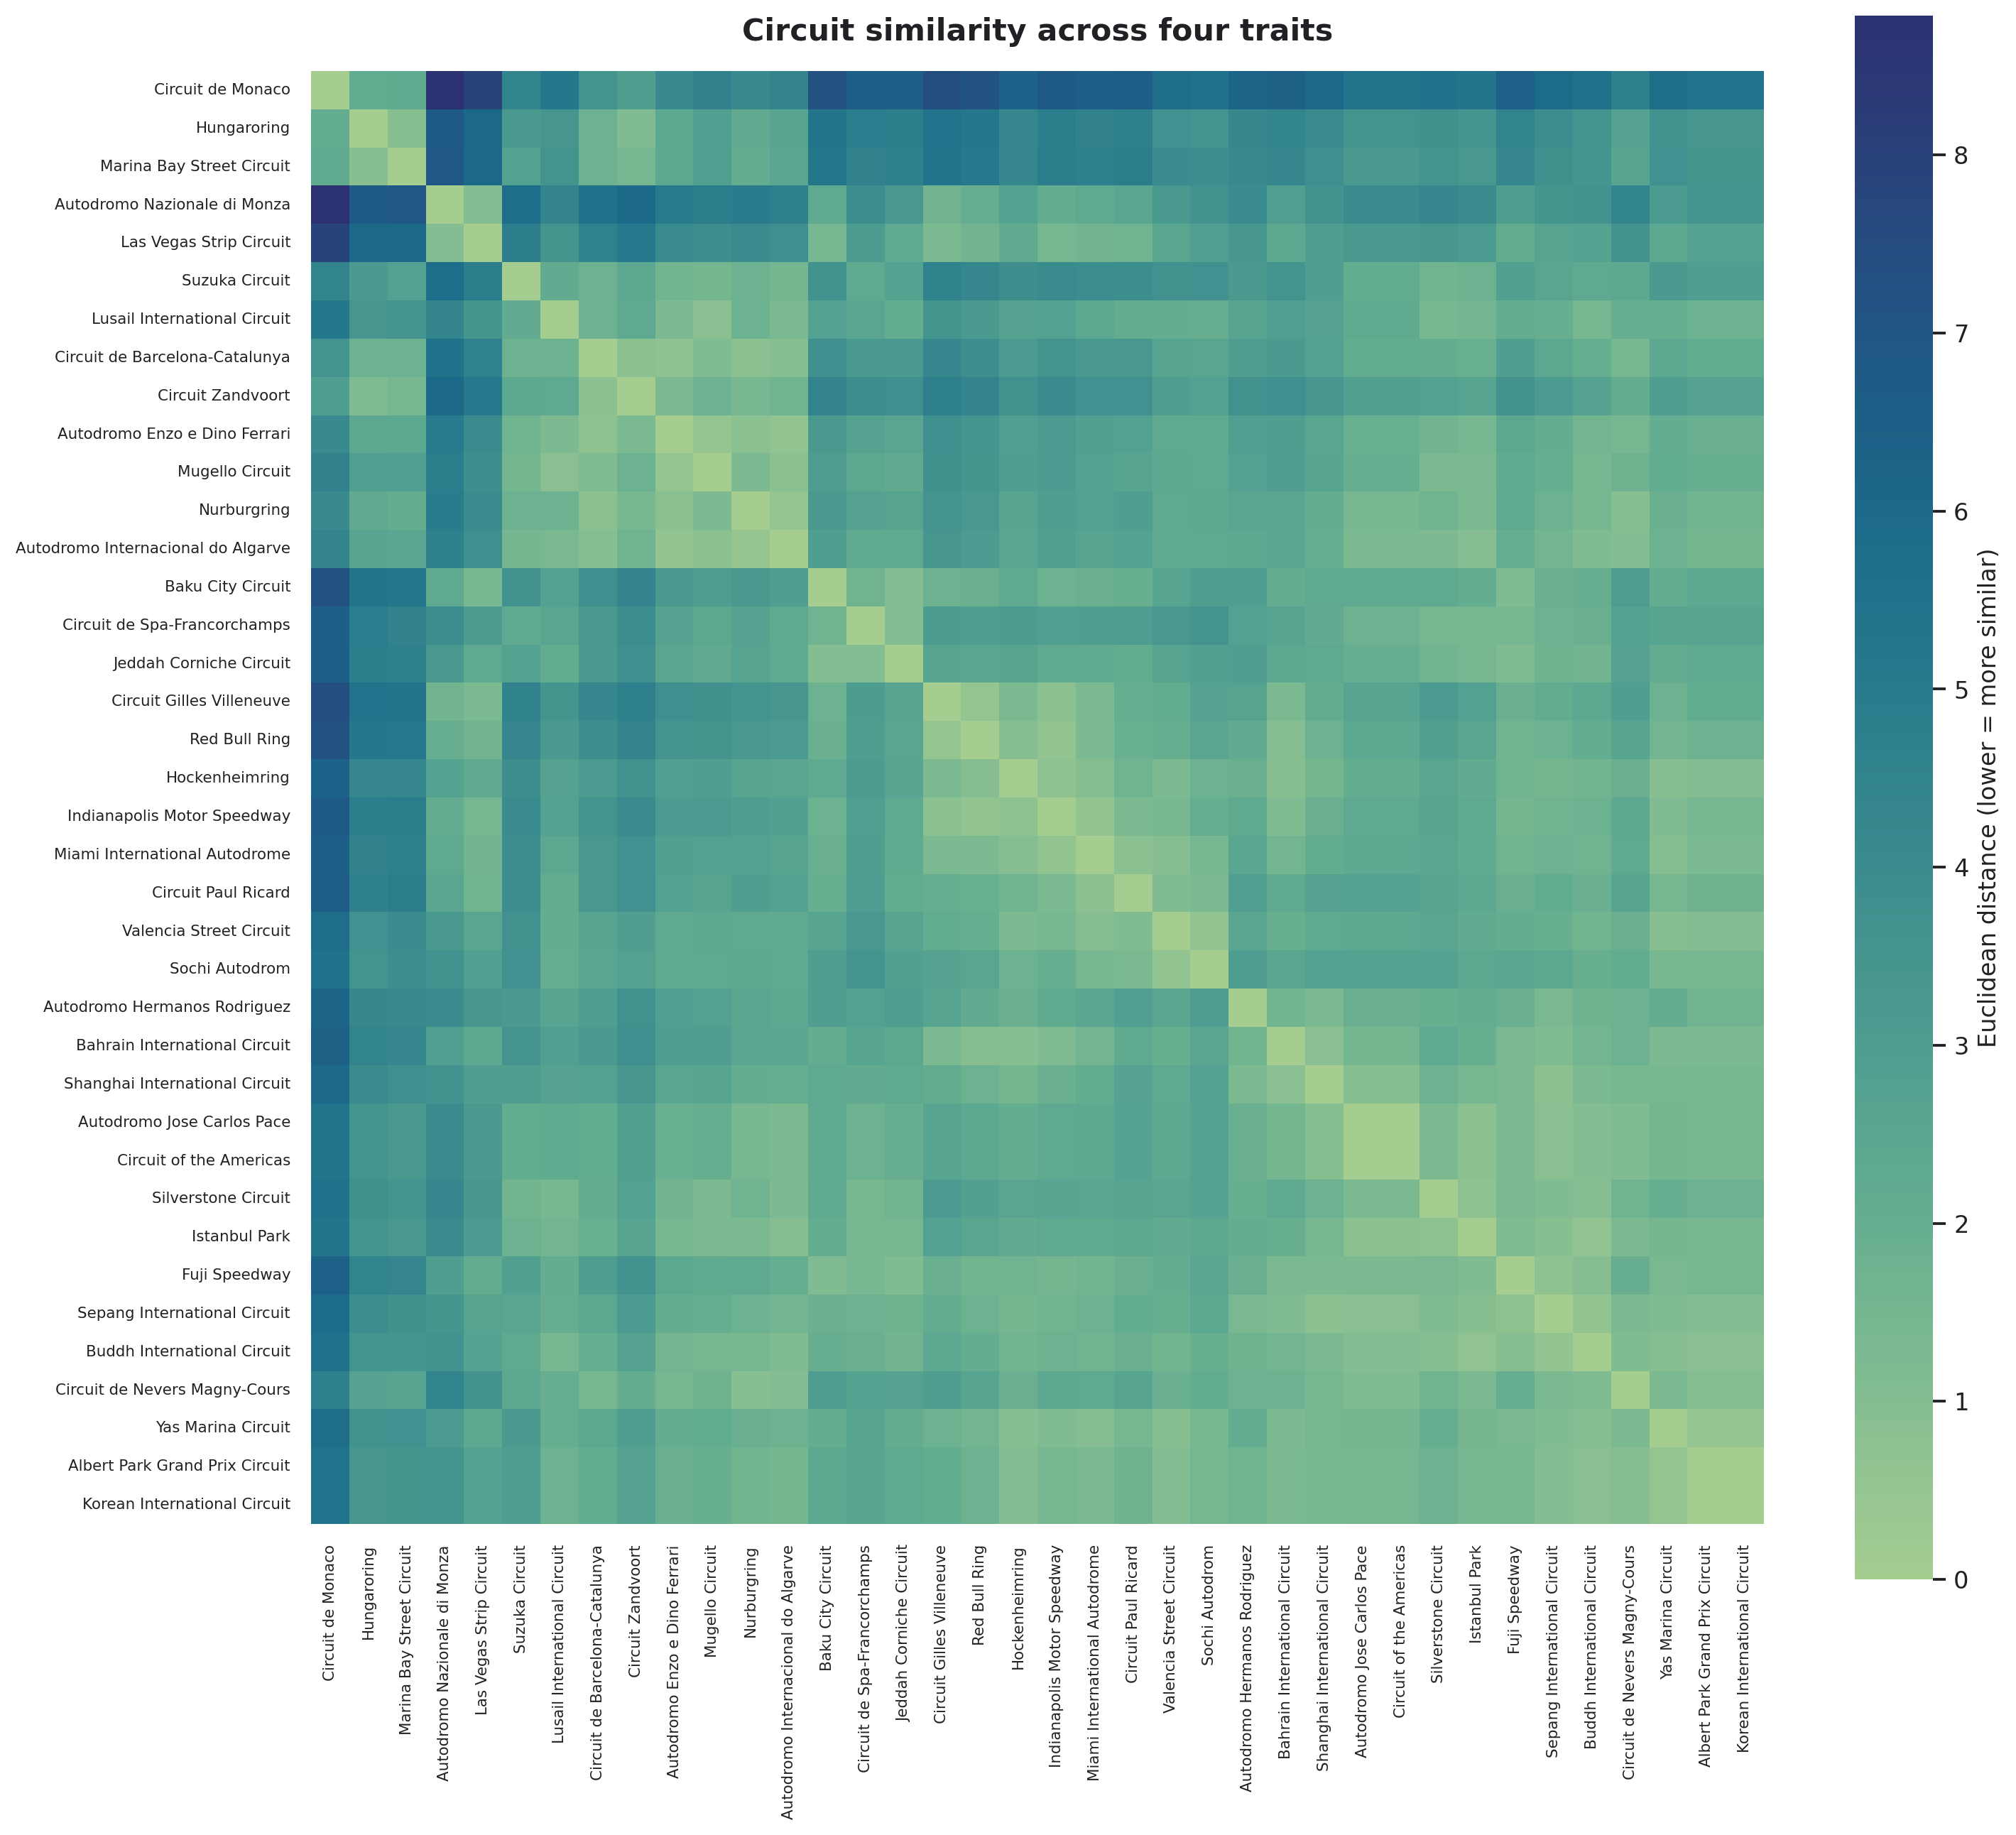

### What this analysis cannot establish

- It does not prove that a circuit causes a driver to perform better.
- It does not rank the greatest drivers.
- It does not isolate circuit traits that overlap with one another.
- It does not estimate changing driver preferences across careers or regulation eras.
- It does not remove every effect of reliability, incidents, strategy, or weather.

The defensible conclusion is narrower: after controlling for grid position and
constructor-season context, some drivers show repeatable historical tendencies across
the modeled circuit dimensions, but those tendencies explain only a small part of the
remaining race-to-race variation.


In [5]:
display(
    Markdown(
        f"""### The central result

The baseline explains **{baseline['r_squared']:.1%}** of driver-race performance variation.
The four circuit models explain about **{specialization_models['r_squared'].mean():.1%}**
of the remaining variation before adjustment and
**{specialization_models['adjusted_r_squared'].mean():.1%}** after adjustment.

Circuit specialization is present, but it is a secondary pattern.

### Versatility is not overall performance

Specialization magnitude and mean outperformance have a correlation of
**{correlation:.2f}**. Drivers can therefore be versatile, strong relative to expectation,
both, or neither.
"""
    )
)

display(
    storytelling_driver_profiles[
        [
            "driver_full_name",
            "mean_outperformance_points",
            "overall_outperformance_rank",
            "versatility_rank",
            "strongest_preference",
            "strongest_slope_points",
        ]
    ].round(2)
)

for interpretation in storytelling_driver_profiles["interpretation"]:
    display(Markdown(f"- {interpretation}"))

display(Image(filename=str(FIGURE_PATHS["versatility"])))
display(Image(filename=str(FIGURE_PATHS["specialists"])))

display(
    Markdown(
        """### Circuit fingerprints and performance separation

Circuit scores describe track profiles; they do not assign difficulty or quality.
The table below ranks circuits with at least 100 modeled observations by the historical
spread of baseline residuals. A wider spread may reflect incidents, reliability, weather,
field composition, or strategy as well as genuine driver-track interaction.
"""
    )
)
display(
    storytelling_circuit_profiles[
        [
            "separation_rank",
            "circuit_name",
            "observations",
            "seasons",
            "residual_std",
            "circuit_type",
            "primary_trait",
        ]
    ].head(10).round(3)
)
display(Image(filename=str(FIGURE_PATHS["circuit_fingerprints"])))
display(Image(filename=str(FIGURE_PATHS["circuit_similarity"])))

display(
    Markdown(
        """### What this analysis cannot establish

- It does not prove that a circuit causes a driver to perform better.
- It does not rank the greatest drivers.
- It does not isolate circuit traits that overlap with one another.
- It does not estimate changing driver preferences across careers or regulation eras.
- It does not remove every effect of reliability, incidents, strategy, or weather.

The defensible conclusion is narrower: after controlling for grid position and
constructor-season context, some drivers show repeatable historical tendencies across
the modeled circuit dimensions, but those tendencies explain only a small part of the
remaining race-to-race variation.
"""
    )
)

## Save outputs

In [6]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATHS["summary"].write_text(
    json.dumps(json_ready(storytelling_summary), indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)
storytelling_driver_profiles.to_csv(OUTPUT_PATHS["drivers"], index=False)
storytelling_circuit_profiles.to_csv(OUTPUT_PATHS["circuits"], index=False)

print(f"Saved {OUTPUT_PATHS['summary'].relative_to(PROJECT_ROOT)}")
print(f"Saved {OUTPUT_PATHS['drivers'].relative_to(PROJECT_ROOT)}")
print(f"Saved {OUTPUT_PATHS['circuits'].relative_to(PROJECT_ROOT)}")

Saved data/outputs/storytelling_summary.json
Saved data/outputs/storytelling_driver_profiles.csv
Saved data/outputs/storytelling_circuit_profiles.csv


## Validation

In [7]:
validation_rows = []

validation_rows.append(
    validation_row(
        "all expected drivers are profiled",
        set(PROFILE_DRIVER_NAMES) == set(storytelling_driver_profiles["driver_full_name"]),
        storytelling_driver_profiles["driver_full_name"].tolist(),
    )
)
validation_rows.append(
    validation_row(
        "headline metrics reproduce model outputs",
        np.isclose(storytelling_summary["baseline"]["r_squared"], baseline["r_squared"])
        and np.isclose(
            storytelling_summary["specialization"]["mean_r_squared"],
            specialization_models["r_squared"].mean(),
        ),
        storytelling_summary["baseline"] | storytelling_summary["specialization"],
    )
)
validation_rows.append(
    validation_row(
        "versatility and outperformance remain separate",
        abs(correlation) < 0.5,
        {"correlation": correlation},
    )
)
validation_rows.append(
    validation_row(
        "circuit separation uses minimum sample",
        bool(storytelling_circuit_profiles["observations"].ge(MIN_CIRCUIT_OBSERVATIONS).all()),
        {
            "minimum_required": MIN_CIRCUIT_OBSERVATIONS,
            "minimum_actual": int(storytelling_circuit_profiles["observations"].min()),
        },
    )
)
validation_rows.append(
    validation_row(
        "circuit metadata merge is complete",
        not storytelling_circuit_profiles[
            ["circuit_type", "speed_score", "technical_score", "downforce_score", "overtaking_score"]
        ].isna().any().any(),
        storytelling_circuit_profiles[
            ["circuit_type", "speed_score", "technical_score", "downforce_score", "overtaking_score"]
        ].isna().sum().to_dict(),
    )
)
validation_rows.append(
    validation_row(
        "all interpretation guardrails are present",
        len(storytelling_summary["interpretation_guardrails"]) == 4,
        storytelling_summary["interpretation_guardrails"],
    )
)
validation_rows.append(
    validation_row(
        "all reused figures exist and are nonempty",
        all(path.exists() and path.stat().st_size > 0 for path in FIGURE_PATHS.values()),
        {name: path.stat().st_size for name, path in FIGURE_PATHS.items()},
    )
)
validation_rows.append(
    validation_row(
        "story outputs contain no absolute local paths",
        not any(
            str(PROJECT_ROOT) in value
            for value in [
                json.dumps(json_ready(storytelling_summary)),
                storytelling_driver_profiles.to_csv(index=False),
                storytelling_circuit_profiles.to_csv(index=False),
            ]
        ),
        None,
    )
)

validation_report = pd.DataFrame(validation_rows)
display(validation_report)

if not validation_report["passed"].all():
    failed = validation_report.loc[~validation_report["passed"], "check"].tolist()
    raise AssertionError(f"Notebook 6 validation failed: {failed}")

OUTPUT_PATHS["validation"].write_text(
    json.dumps(validation_rows, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)
print("PASS")

,check,passed,details
0,all expected drivers are profiled,True,"[Max Verstappen, Fernando Alonso, Alexander Al..."
1,headline metrics reproduce model outputs,True,"{'r_squared': 0.4555996964336545, 'adjusted_r_..."
2,versatility and outperformance remain separate,True,{'correlation': -0.18169765698014598}
3,circuit separation uses minimum sample,True,"{'minimum_required': 100, 'minimum_actual': 100}"
4,circuit metadata merge is complete,True,"{'circuit_type': 0, 'speed_score': 0, 'technic..."
5,all interpretation guardrails are present,True,[Specialization is not an all-time driver rank...
6,all reused figures exist and are nonempty,True,"{'specialists': 504493, 'heatmap': 338299, 've..."
7,story outputs contain no absolute local paths,True,None


PASS


## Supercheck

In [8]:
supercheck_rows = []

for output_name in ["summary", "drivers", "circuits", "validation"]:
    output_path = OUTPUT_PATHS[output_name]
    supercheck_rows.append(
        validation_row(
            f"{output_name} file exists",
            output_path.exists() and output_path.stat().st_size > 0,
            str(output_path.relative_to(PROJECT_ROOT)),
        )
    )

saved_summary = json.loads(OUTPUT_PATHS["summary"].read_text(encoding="utf-8"))
saved_drivers = pd.read_csv(OUTPUT_PATHS["drivers"])
saved_circuits = pd.read_csv(OUTPUT_PATHS["circuits"])
saved_validation = json.loads(OUTPUT_PATHS["validation"].read_text(encoding="utf-8"))

supercheck_rows.extend(
    [
        validation_row(
            "saved summary equals memory",
            saved_summary == json_ready(storytelling_summary),
            None,
        ),
        validation_row(
            "saved driver profiles equal memory",
            saved_drivers.equals(pd.read_csv(OUTPUT_PATHS["drivers"]))
            and len(saved_drivers) == len(storytelling_driver_profiles),
            {"rows": len(saved_drivers), "columns": len(saved_drivers.columns)},
        ),
        validation_row(
            "saved circuit profiles equal memory",
            saved_circuits.equals(pd.read_csv(OUTPUT_PATHS["circuits"]))
            and len(saved_circuits) == len(storytelling_circuit_profiles),
            {"rows": len(saved_circuits), "columns": len(saved_circuits.columns)},
        ),
        validation_row(
            "saved validation report equals memory",
            saved_validation == json_ready(validation_rows),
            None,
        ),
    ]
)

supercheck_report = pd.DataFrame(supercheck_rows)
display(supercheck_report)

if not supercheck_report["passed"].all():
    failed = supercheck_report.loc[~supercheck_report["passed"], "check"].tolist()
    raise AssertionError(f"Notebook 6 supercheck failed: {failed}")

print("PASS")

,check,passed,details
0,summary file exists,True,data/outputs/storytelling_summary.json
1,drivers file exists,True,data/outputs/storytelling_driver_profiles.csv
2,circuits file exists,True,data/outputs/storytelling_circuit_profiles.csv
3,validation file exists,True,data/outputs/notebook_06_validation_report.json
4,saved summary equals memory,True,None
5,saved driver profiles equal memory,True,"{'rows': 5, 'columns': 11}"
6,saved circuit profiles equal memory,True,"{'rows': 27, 'columns': 15}"
7,saved validation report equals memory,True,None


PASS
